# SDSC2005 — Exploratory analysis: FakeNewsNet

**Research question:** Can linguistic features distinguish fake news from real news?

**Why it matters:** Misinformation spreads quickly online; understanding surface-language signals can suggest practical checks for readers and complement platform-side tools (without replacing fact-checking or source verification).

This notebook loads the [FakeNewsNet](https://www.kaggle.com/datasets/mdepak/fakenewsnet) snapshot from Kaggle (via `kagglehub`), carries out **Subtask 1** (descriptive linguistics + VADER on FakeNewsNet) and **Subtask 2** (combined FakeNewsNet + LIAR + ISOT corpus, **multi-view** TF-IDF + sentence embeddings, **stacked** meta-learner, held-out test metrics), aligned with the SDSC2005 group proposal.


## Dataset description (Kaggle + published FakeNewsNet)

**What it is:** FakeNewsNet is a research repository for studying misinformation on social media. The original work ([arXiv:1809.01286](https://arxiv.org/abs/1809.01286)) describes news content together with **social context** and **spatiotemporal** signals (e.g., propagation). The full corpus cannot always be redistributed in full due to publisher and platform constraints.

**This Kaggle bundle (`mdepak/fakenewsnet`):** It includes **article-level content** for articles labeled from two fact-checking sources:

| Source | Role in literature |
|--------|----------------------|
| **PolitiFact** | U.S. political fact-checking; fake vs. real political stories |
| **BuzzFeed** | A second benchmark subset (often entertainment/gossip-oriented) |

**Files used here:** `*_fake_news_content.csv` and `*_real_news_content.csv` for PolitiFact and BuzzFeed. Each row has metadata such as `id`, `title`, `text`, `url`, `authors`, `publish_date`, and `source`, plus fields like `images` / `meta_data` scraped from pages.

**Labels:** `fake` vs. `real` are provided by the dataset construction (aligned with PolitiFact / BuzzFeed curation), not predicted by this notebook.


In [ ]:
! pip3 install kagglehub pandas numpy matplotlib seaborn scipy nltk scikit-learn sentence-transformers


In [ ]:
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)


In [ ]:
# Download latest version (cached after first run)
path_str = kagglehub.dataset_download("mdepak/fakenewsnet")
DATA_DIR = Path(path_str)
print("Path to dataset files:", DATA_DIR)


Path to dataset files: /Users/bernar/.cache/kagglehub/datasets/mdepak/fakenewsnet/versions/1


In [ ]:
# Load PolitiFact + BuzzFeed fake/real article tables
parts = []
for fname, site, label in [
    ("PolitiFact_fake_news_content.csv", "PolitiFact", "fake"),
    ("PolitiFact_real_news_content.csv", "PolitiFact", "real"),
    ("BuzzFeed_fake_news_content.csv", "BuzzFeed", "fake"),
    ("BuzzFeed_real_news_content.csv", "BuzzFeed", "real"),
]:
    p = DATA_DIR / fname
    d = pd.read_csv(p)
    d["news_source"] = site
    d["label"] = label
    parts.append(d)

df = pd.concat(parts, ignore_index=True)
df["text"] = df["text"].fillna("").astype(str)
df["title"] = df["title"].fillna("").astype(str)

df.head()


,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data,news_source,label
0,Real_1-Webpage,Trump Just Insulted Millions Who Lost Everythi...,16.8k SHARES SHARE THIS STORY\n\nHillary Clint...,http://occupydemocrats.com/2016/09/27/trump-ju...,http://occupydemocrats.com/wp-content/uploads/...,"Brett Bose,Grant Stern,Steve Bernstein,Natalie...",http://occupydemocrats.com,{'$date': 1474934400000},NaN,http://occupydemocrats.com/wp-content/uploads/...,http://occupydemocrats.com/2016/09/27/trump-ju...,"{""generator"": ""Powered by Visual Composer - dr...",PolitiFact,fake
1,Real_10-Webpage,Famous dog killed in spot she waited a year fo...,Famous dog killed in spot she waited a year fo...,http://rightwingnews.com/top-news/famous-dog-k...,http://rightwingnews.com/wp-content/uploads/20...,NaN,http://rightwingnews.com,{'$date': 1474948336000},NaN,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/top-news/famous-dog-k...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam...",PolitiFact,fake
2,Real_100-Webpage,House oversight panel votes Clinton IT chief i...,Story highlights The House Oversight panel vot...,http://cnn.it/2deaH2d,http://i2.cdn.cnn.com/cnnnext/dam/assets/16091...,"Tom Lobianco,Deirdre Walsh",http://cnn.it,NaN,NaN,http://i2.cdn.cnn.com/cnnnext/dam/assets/17050...,http://www.cnn.com/2016/09/22/politics/bryan-p...,"{""description"": ""Members of the House Oversigh...",PolitiFact,fake
3,Real_101-Webpage,America Just Tragically Lost A Country Music I...,We are absolutely heartbroken to hear about th...,http://newsbake.com/entertainment-news/music-e...,http://newsbake.com/wp-content/uploads/2016/05...,Nancy Wells,http://newsbake.com,{'$date': 1474898600000},https://www.youtube.com/embed/8ozTJcu-_BU,http://0.gravatar.com/avatar/0d702c6042933cd78...,http://newsbake.com/entertainment-news/music-e...,"{""shareaholic"": {""site_name"": ""NewsBake"", ""lan...",PolitiFact,fake
4,Real_102-Webpage,Monuments to the Battle for the New South,"Nine years ago, a driver lost control of his p...",http://politi.co/2dd9U1x,http://static.politico.com/25/ed/85332de14c45b...,"Jack Shafer,Lisa Rab",http://politi.co,{'$date': 1473941820000},NaN,http://static.politico.com/25/ed/85332de14c45b...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""Virginia, increasingly divers...",PolitiFact,fake


In [ ]:
# Class balance and schema
summary = pd.DataFrame({
    "rows": [len(df)],
    "fake": [(df["label"] == "fake").sum()],
    "real": [(df["label"] == "real").sum()],
})
display(summary)
print("By fact-check source and label:")
display(df.groupby(["news_source", "label"]).size().rename("n").reset_index())
print("\nColumns:", list(df.columns))


,rows,fake,real
0,422,211,211


By fact-check source and label:


,news_source,label,n
0,BuzzFeed,fake,91
1,BuzzFeed,real,91
2,PolitiFact,fake,120
3,PolitiFact,real,120



Columns: ['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data', 'news_source', 'label']


In [ ]:
# Missingness in key text fields
for col in ["text", "title", "authors", "publish_date"]:
    if col in df.columns:
        na = df[col].isna().sum() + (df[col].astype(str).str.strip() == "").sum()
        print(f"{col}: empty or NaN rows = {na}")


text: empty or NaN rows = 0
title: empty or NaN rows = 0
authors: empty or NaN rows = 67
publish_date: empty or NaN rows = 127


## Subtask 1: Descriptive analysis

### Linguistic features

We compute simple, interpretable features aligned with the proposal: article length, sentence length, type–token ratio (lexical diversity proxy), punctuation and “shouting” (caps), plus **VADER** compound sentiment on full `text`.


In [ ]:
import re
import string

import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize

STOP = set(stopwords.words("english"))
SID = SentimentIntensityAnalyzer()


def tokenize_words(text: str):
    return word_tokenize(text.lower())


def ling_features(text: str, title: str = ""):
    text = text or ""
    title = title or ""
    words = re.findall(r"\b\w+\b", text.lower())
    n_words = len(words)
    n_chars = len(text)
    sents = sent_tokenize(text) if text.strip() else []
    n_sents = max(len(sents), 1)
    uniq = len(set(words))
    ttr = uniq / n_words if n_words else 0.0
    punct = sum(1 for c in text if c in string.punctuation)
    punct_rate = punct / n_chars if n_chars else 0.0
    upper = sum(1 for c in text if c.isupper())
    upper_rate = upper / n_chars if n_chars else 0.0
    excl = text.count("!")
    excl_per_1k = 1000 * excl / n_words if n_words else 0.0
    title_excl = title.count("!")
    v = SID.polarity_scores(text)
    return {
        "n_chars": n_chars,
        "n_words": n_words,
        "words_per_sent": n_words / n_sents,
        "ttr": ttr,
        "punct_rate": punct_rate,
        "upper_rate": upper_rate,
        "excl_per_1k": excl_per_1k,
        "title_excl": title_excl,
        "vader_compound": v["compound"],
        "vader_pos": v["pos"],
        "vader_neg": v["neg"],
        "vader_neu": v["neu"],
    }


feat_rows = [ling_features(t, tit) for t, tit in zip(df["text"], df["title"])]
feat = pd.DataFrame(feat_rows)
eda = pd.concat([df[["id", "news_source", "label"]], feat], axis=1)
eda.head()


,id,news_source,label,n_chars,n_words,words_per_sent,ttr,punct_rate,upper_rate,excl_per_1k,title_excl,vader_compound,vader_pos,vader_neg,vader_neu
0,Real_1-Webpage,PolitiFact,fake,1355,235,39.166667,0.629787,0.017712,0.049446,4.255319,0,-0.9359,0.118,0.175,0.707
1,Real_10-Webpage,PolitiFact,fake,2297,428,25.176471,0.528037,0.017849,0.025686,2.336449,1,-0.9474,0.061,0.098,0.841
2,Real_100-Webpage,PolitiFact,fake,1286,207,25.875000,0.579710,0.026439,0.041991,0.000000,0,-0.8957,0.059,0.118,0.824
3,Real_101-Webpage,PolitiFact,fake,1988,381,19.050000,0.506562,0.016097,0.040241,0.000000,0,0.9841,0.146,0.052,0.802
4,Real_102-Webpage,PolitiFact,fake,13273,2209,24.544444,0.368945,0.021397,0.030965,0.000000,0,0.9232,0.083,0.072,0.844


In [ ]:
# Compare fake vs. real (overall); report effect sizes via Cohen's d
feat_cols = [
    "n_chars",
    "n_words",
    "words_per_sent",
    "ttr",
    "punct_rate",
    "upper_rate",
    "excl_per_1k",
    "title_excl",
    "vader_compound",
    "vader_pos",
    "vader_neg",
]


def cohen_d(x1, x2):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = len(x1), len(x2)
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    pooled = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (x1.mean() - x2.mean()) / pooled if pooled > 0 else np.nan


rows = []
for c in feat_cols:
    f = eda.loc[eda["label"] == "fake", c]
    r = eda.loc[eda["label"] == "real", c]
    stat, p = stats.mannwhitneyu(f, r, alternative="two-sided")
    rows.append(
        {
            "feature": c,
            "mean_fake": f.mean(),
            "mean_real": r.mean(),
            "cohen_d_fake_minus_real": cohen_d(f, r),
            "mannwhitney_p": p,
        }
    )
compare = pd.DataFrame(rows).sort_values("mannwhitney_p")
display(compare)


,feature,mean_fake,mean_real,cohen_d_fake_minus_real,mannwhitney_p
4,punct_rate,0.023373,0.025855,-0.350346,0.000136
7,title_excl,0.165877,0.042654,0.357812,0.000183
6,excl_per_1k,1.518871,1.109373,0.088642,0.015666
2,words_per_sent,23.180111,24.116538,-0.146313,0.057191
10,vader_neg,0.098882,0.090512,0.160956,0.118789
8,vader_compound,-0.196322,-0.066033,-0.149918,0.130052
9,vader_pos,0.082526,0.084550,-0.051786,0.564627
1,n_words,581.568720,643.597156,-0.087719,0.688033
3,ttr,0.531910,0.525765,0.062678,0.748590
0,n_chars,3391.170616,3762.156398,-0.089330,0.770773


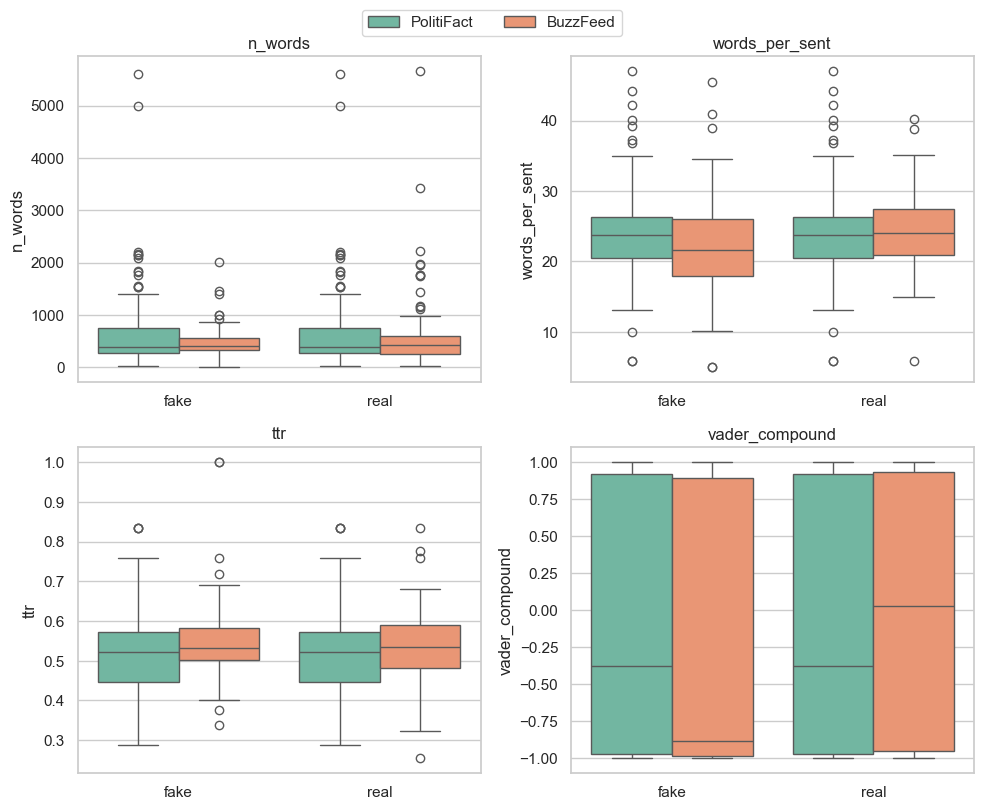

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_feats = ["n_words", "words_per_sent", "ttr", "vader_compound"]
for ax, col in zip(axes.ravel(), plot_feats):
    sns.boxplot(data=eda, x="label", y=col, hue="news_source", ax=ax, palette="Set2")
    ax.set_title(col)
    ax.set_xlabel("")
handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.ravel():
    ax.legend_.remove()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()


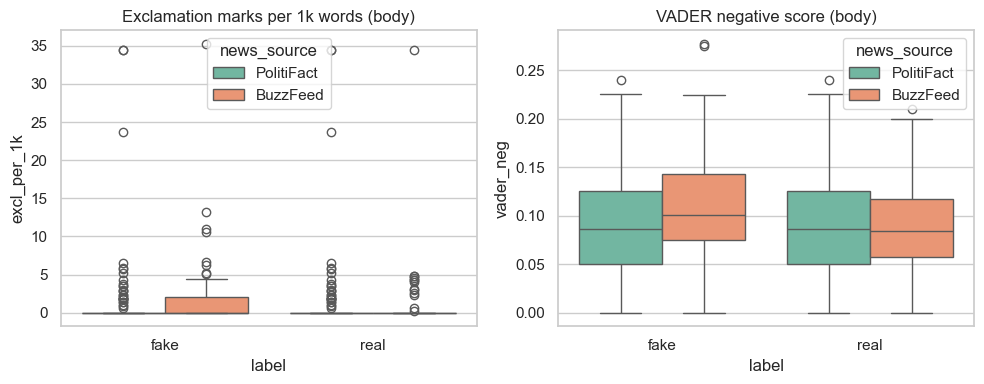

In [ ]:
# Emotional “activation” proxies: exclamation marks and VADER negative component
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=eda, x="label", y="excl_per_1k", hue="news_source", ax=axes[0], palette="Set2")
axes[0].set_title("Exclamation marks per 1k words (body)")
sns.boxplot(data=eda, x="label", y="vader_neg", hue="news_source", ax=axes[1], palette="Set2")
axes[1].set_title("VADER negative score (body)")
plt.tight_layout()
plt.show()


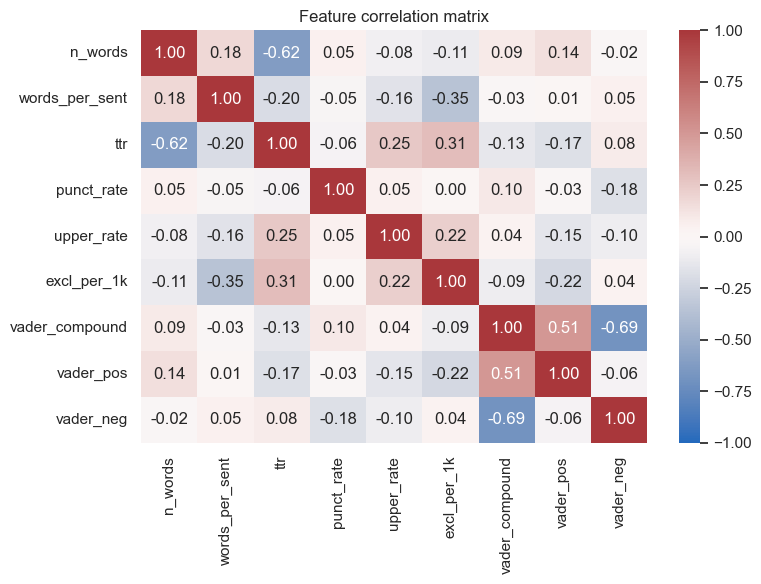

In [ ]:
# Correlation heatmap (linguistic + sentiment features)
corr_cols = [
    "n_words",
    "words_per_sent",
    "ttr",
    "punct_rate",
    "upper_rate",
    "excl_per_1k",
    "vader_compound",
    "vader_pos",
    "vader_neg",
]
cm = eda[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


#### Interpreting the correlation heatmap

- **`n_words` vs. `ttr` (~−0.62):** Longer articles repeat words more often, so type–token ratio falls. Treat these as **partially redundant** for linear models (e.g., logistic regression may spread weight across both).
- **VADER components:** `vader_compound` is strongly related to `vader_pos` / `vader_neg` by construction. Using **all** VADER columns together adds **multicollinearity**; for interpretation, `vader_compound` alone often suffices.
- **`punct_rate` / `upper_rate`:** These sit near **zero** correlation with several other features, so they can add **orthogonal** information alongside length and sentiment.


## Subtask 2: Stacking classifier

FakeNewsNet alone (\~422 articles) is too small for reliable supervised learning on bag-of-words alone. This block **augments** it with **LIAR** (political claims, binarized) and **ISOT** (fake vs. real news articles), then **deduplicates** statements and shuffles. The printout reports the final row count (on the order of **\~52k** rows).

### Why multiple views help
Different representations catch different cues:
- **Word TF-IDF** — vocabulary and phrases  
- **Char TF-IDF** (3–5 character n-grams) — style, punctuation, sub-word patterns  
- **Sentence embeddings** (`all-MiniLM-L6-v2`, 384 dims) — coarse semantics  

### Stacking strategy (Level-0 → Level-1)

**Level-0 base models** (one feature view each):
1. **Logistic regression + word TF-IDF** (`max_features=5000`, unigrams–bigrams, `sublinear_tf`, `min_df=2`)  
2. **Calibrated LinearSVC + char TF-IDF** (`max_features=5000`, char n-grams 3–5, `sublinear_tf`)  
3. **Random forest + word TF-IDF** (same matrix as (1))  
4. **Logistic regression + sentence embeddings**  

**Level-1 meta-model:** **Logistic regression** fit on **out-of-fold predicted probabilities** from the four bases on the **training** split (5-fold stratified), then refit bases on full train and applied to the **held-out 20%** test split (`random_state=42`, stratified). OOF stacking avoids the meta-learner seeing in-sample base predictions for training rows.

**Evaluation:** per-class precision/recall/F1, accuracy, **macro F1**, **ROC-AUC**, confusion matrix, macro-F1 bar chart, meta-model coefficients.

*Note:* Labels are coded **1 = real**, **0 = fake** for LIAR and ISOT; FakeNewsNet rows use the same convention in code. Re-run the data-merge cell after any change so counts and metrics stay consistent.


100%|██████████| 0.98M/0.98M [00:00<00:00, 1.95MB/s]

Extracting files...


100%|██████████| 41.0M/41.0M [00:02<00:00, 14.7MB/s]


Extracting files...
Combined corpus: 52,157 articles  |  real=25,898  fake=26,259

Generating sentence embeddings — may take a few minutes…


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/163 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]


Feature shapes (train):
  Word TF-IDF : (41725, 5000)
  Char TF-IDF : (41725, 5000)
  Embeddings  : (41725, 384)

Training base model 1: LR + Word TF-IDF…
Training base model 2: SVM + Char TF-IDF…
Training base model 3: Random Forest + Word TF-IDF…
Training base model 4: LR + Sentence Embeddings…

Base 1 — LR + Word TF-IDF
              precision    recall  f1-score   support

        real     0.8718    0.9450    0.9069      5252
        fake     0.9390    0.8591    0.8973      5180

    accuracy                         0.9023     10432
   macro avg     0.9054    0.9020    0.9021     10432
weighted avg     0.9052    0.9023    0.9021     10432

  ROC-AUC : 0.9700

Base 2 — SVM (calibrated) + Char TF-IDF
              precision    recall  f1-score   support

        real     0.8824    0.9400    0.9103      5252
        fake     0.9349    0.8730    0.9029      5180

    accuracy                         0.9067     10432
   macro avg     0.9086    0.9065    0.9066     10432
weighted avg   

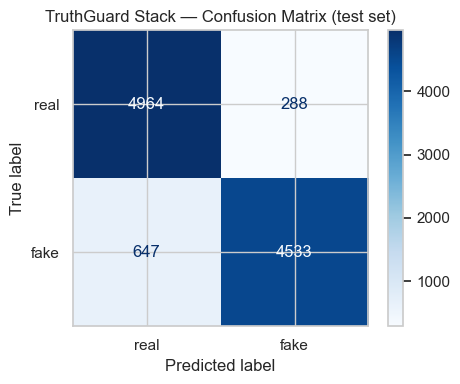

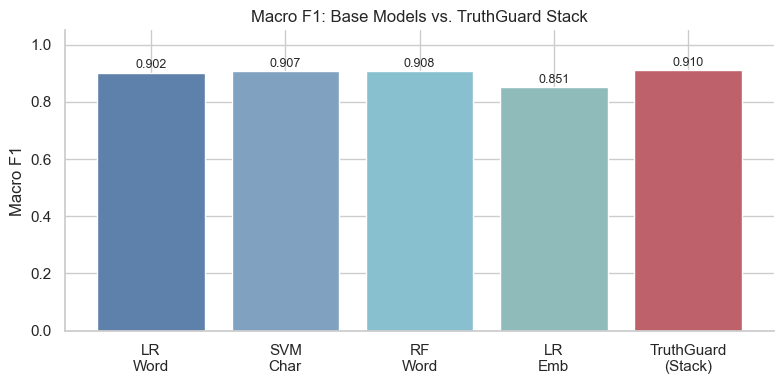


Meta-model logit coefficients (higher = base model trusted more):
  LR-word     : +1.1986
  SVM-char    : +3.3879
  RF-word     : +4.2929
  LR-emb      : +0.8021


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Part A: Multi-dataset integration
# ─────────────────────────────────────────────────────────────────────────────
# FakeNewsNet alone has ~422 articles — far too few for stacking to help.
# LIAR adds ~12 k political claims; ISOT adds ~39 k news articles.
# Together they produce a ~51 k corpus with diverse writing styles and topics.

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import LinearSVC
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

# ── LIAR dataset (6-class political claims → binary) ─────────────────────────
liar_dl = Path(kagglehub.dataset_download("csmalarkodi/liar-fake-news-dataset"))
liar_cols = [
    "ID", "label", "statement", "subjects", "speaker", "speaker_job",
    "state", "party", "barely_true_cnt", "false_cnt", "half_true_cnt",
    "mostly_true_cnt", "pants_fire_cnt", "venue",
]
df_liar = pd.concat(
    [pd.read_csv(liar_dl / split, sep="\t", header=None, names=liar_cols)
     for split in ["train.tsv", "valid.tsv", "test.tsv"]],
    ignore_index=True,
)
# true / mostly-true → 1 (real); everything else → 0 (fake / misleading)
liar_map = {
    "true": 1, "mostly-true": 1,
    "half-true": 0, "barely-true": 0, "false": 0, "pants-fire": 0,
}
df_liar = df_liar[df_liar["label"].isin(liar_map)].copy()
df_liar["label"] = df_liar["label"].map(liar_map)
df_liar = df_liar[["statement", "label"]].dropna().drop_duplicates()

# ── ISOT dataset (17 k fake + 17 k real news articles) ───────────────────────
isot_dl = Path(kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset"))
df_isot = pd.concat([
    pd.read_csv(isot_dl / "Fake.csv").assign(label=0),
    pd.read_csv(isot_dl / "True.csv").assign(label=1),
], ignore_index=True)
df_isot["statement"] = (
    df_isot["title"].fillna("") + " " + df_isot["text"].fillna("")
).str.strip()
df_isot = df_isot[["statement", "label"]].dropna().drop_duplicates()

# ── FakeNewsNet (already loaded as `df` in the data-loading cell) ─────────────
df_fnn = df.copy()
df_fnn["statement"] = (
    df_fnn["title"].fillna("") + " " + df_fnn["text"].fillna("")
).str.strip()
df_fnn["label"] = (df_fnn["label"] == "real").astype(int)  # 1=real, 0=fake (same as LIAR/ISOT)
df_fnn = df_fnn[["statement", "label"]].dropna().drop_duplicates()

# ── Unified corpus ─────────────────────────────────────────────────────────────
corpus = (
    pd.concat([df_fnn, df_liar, df_isot], ignore_index=True)
    .drop_duplicates(subset="statement")
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(
    f"Combined corpus: {len(corpus):,} articles  |  "
    f"real={(corpus['label'] == 1).sum():,}  fake={(corpus['label'] == 0).sum():,}"
)

# ─────────────────────────────────────────────────────────────────────────────
# Part B: Feature extraction — three complementary views of each text
# ─────────────────────────────────────────────────────────────────────────────
# Each view captures a different signal that the others miss:
#   Word TF-IDF  → vocabulary / phrase patterns
#   Char TF-IDF  → stylistic and sub-word cues (punctuation, spelling quirks)
#   Embeddings   → semantic meaning regardless of exact wording

all_texts = corpus["statement"].tolist()
all_labels = corpus["label"].to_numpy()

X_tr_txt, X_te_txt, y_train, y_test = train_test_split(
    all_texts, all_labels, test_size=0.2, random_state=42, stratify=all_labels,
)

# 1. Word-level TF-IDF: unigrams + bigrams
word_vec = TfidfVectorizer(
    max_features=5_000, ngram_range=(1, 2), sublinear_tf=True, min_df=2,
)
X_tr_word = word_vec.fit_transform(X_tr_txt)
X_te_word = word_vec.transform(X_te_txt)

# 2. Character-level TF-IDF: trigrams to 5-grams
char_vec = TfidfVectorizer(
    analyzer="char", max_features=5_000, ngram_range=(3, 5), sublinear_tf=True,
)
X_tr_char = char_vec.fit_transform(X_tr_txt)
X_te_char = char_vec.transform(X_te_txt)

# 3. Sentence embeddings via MiniLM-L6-v2 (384-dimensional dense vectors)
print("\nGenerating sentence embeddings — may take a few minutes…")
sem_model = SentenceTransformer("all-MiniLM-L6-v2")
X_tr_emb = sem_model.encode(
    X_tr_txt, batch_size=256, show_progress_bar=True, convert_to_numpy=True
)
X_te_emb = sem_model.encode(
    X_te_txt, batch_size=256, show_progress_bar=True, convert_to_numpy=True
)

print("\nFeature shapes (train):")
print(f"  Word TF-IDF : {X_tr_word.shape}")
print(f"  Char TF-IDF : {X_tr_char.shape}")
print(f"  Embeddings  : {X_tr_emb.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Part C: Base models with out-of-fold (OOF) stacking
# ─────────────────────────────────────────────────────────────────────────────
# Each base model is trained on 4 folds and predicts the held-out 5th fold.
# Collecting predictions across all folds produces a full-training-set estimate
# of each model's class probabilities without overfitting the meta-model.

def get_oof_proba(base_model, X_train, y_train, n_splits=5):
    """
    Run stratified k-fold CV and return out-of-fold P(class=1) for every
    training sample. Uses clone() so the original model is not mutated.
    """
    oof = np.zeros(len(y_train))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in skf.split(X_train, y_train):
        m = clone(base_model)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        oof[val_idx] = m.predict_proba(X_train[val_idx])[:, 1]
    return oof


# Base model 1: Logistic Regression on word TF-IDF
print("\nTraining base model 1: LR + Word TF-IDF…")
lr_word = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
oof_lr_word = get_oof_proba(lr_word, X_tr_word, y_train)
lr_word.fit(X_tr_word, y_train)

# Base model 2: Calibrated LinearSVC on char TF-IDF
# LinearSVC is fast and excellent for char n-gram features;
# CalibratedClassifierCV wraps it to produce proper probability estimates.
print("Training base model 2: SVM + Char TF-IDF…")
svm_char = CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42), cv=3)
oof_svm_char = get_oof_proba(svm_char, X_tr_char, y_train)
svm_char.fit(X_tr_char, y_train)

# Base model 3: Random Forest on word TF-IDF
# Tree-based bias produces error patterns different from the linear models above.
print("Training base model 3: Random Forest + Word TF-IDF…")
rf_word = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
oof_rf_word = get_oof_proba(rf_word, X_tr_word, y_train)
rf_word.fit(X_tr_word, y_train)

# Base model 4: Logistic Regression on sentence embeddings
# Dense semantic features catch meaning regardless of exact wording.
print("Training base model 4: LR + Sentence Embeddings…")
lr_emb = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
oof_lr_emb = get_oof_proba(lr_emb, X_tr_emb, y_train)
lr_emb.fit(X_tr_emb, y_train)

# ─────────────────────────────────────────────────────────────────────────────
# Part D: Meta-model — Level-1 logistic regression
# ─────────────────────────────────────────────────────────────────────────────
# Stack the 4 OOF probability columns into an (n_train × 4) matrix.
# A Logistic Regression learns to weight the base-model opinions per example.

meta_train = np.column_stack([oof_lr_word, oof_svm_char, oof_rf_word, oof_lr_emb])
meta_clf = LogisticRegression(max_iter=1000, random_state=42)
meta_clf.fit(meta_train, y_train)

# For the test set: feed each base model's probabilities into the meta-model
meta_test = np.column_stack([
    lr_word.predict_proba(X_te_word)[:, 1],
    svm_char.predict_proba(X_te_char)[:, 1],
    rf_word.predict_proba(X_te_word)[:, 1],
    lr_emb.predict_proba(X_te_emb)[:, 1],
])
stack_preds = meta_clf.predict(meta_test)
stack_proba = meta_clf.predict_proba(meta_test)[:, 1]

# ─────────────────────────────────────────────────────────────────────────────
# Part E: Evaluation — base models vs. stacked ensemble
# ─────────────────────────────────────────────────────────────────────────────

def print_report(name, y_true, y_pred, y_proba=None):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=["real", "fake"], digits=4))
    if y_proba is not None:
        print(f"  ROC-AUC : {roc_auc_score(y_true, y_proba):.4f}")


print_report(
    "Base 1 — LR + Word TF-IDF",
    y_test, lr_word.predict(X_te_word),
    lr_word.predict_proba(X_te_word)[:, 1],
)
print_report(
    "Base 2 — SVM (calibrated) + Char TF-IDF",
    y_test, svm_char.predict(X_te_char),
    svm_char.predict_proba(X_te_char)[:, 1],
)
print_report(
    "Base 3 — Random Forest + Word TF-IDF",
    y_test, rf_word.predict(X_te_word),
    rf_word.predict_proba(X_te_word)[:, 1],
)
print_report(
    "Base 4 — LR + Sentence Embeddings",
    y_test, lr_emb.predict(X_te_emb),
    lr_emb.predict_proba(X_te_emb)[:, 1],
)
print_report("Stacked ensemble (meta-LR)", y_test, stack_preds, stack_proba)

# ─────────────────────────────────────────────────────────────────────────────
# Part F: Visualisations
# ─────────────────────────────────────────────────────────────────────────────

# Confusion matrix for the stacked model
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, stack_preds, display_labels=["real", "fake"], cmap="Blues", ax=ax,
)
ax.set_title("Stacked ensemble — confusion matrix (test set)")
plt.tight_layout()
plt.show()

# Macro F1 bar chart: each base model vs. stacked ensemble
base_labels = ["LR\nWord", "SVM\nChar", "RF\nWord", "LR\nEmb"]
all_labels = base_labels + ["Stack\n(meta-LR)"]
all_model_preds = [
    lr_word.predict(X_te_word),
    svm_char.predict(X_te_char),
    rf_word.predict(X_te_word),
    lr_emb.predict(X_te_emb),
    stack_preds,
]
macro_f1s = [f1_score(y_test, p, average="macro") for p in all_model_preds]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#5E81AC", "#81A1C1", "#88C0D0", "#8FBCBB", "#BF616A"]
bars = ax.bar(all_labels, macro_f1s, color=colors, edgecolor="white")
for bar, val in zip(bars, macro_f1s):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("Macro F1: Base models vs. stacked ensemble")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Meta-model coefficients: which base model does the stack trust most?
print("\nMeta-model logit coefficients (higher = base model trusted more):")
for name, coef in zip(
    ["LR-word", "SVM-char", "RF-word", "LR-emb"], meta_clf.coef_[0]
):
    print(f"  {name:12s}: {coef:+.4f}")


## Summary: findings vs. the research plan

**Proposal coverage:** **Subtask 1** uses **FakeNewsNet** only: engineered linguistic descriptors + **NLTK VADER** on PolitiFact and BuzzFeed articles. **Subtask 2** builds a **larger binary corpus** by merging FakeNewsNet with **LIAR** and **ISOT** (deduplicated statements), then trains **four base learners** on **word TF-IDF**, **char TF-IDF**, and **sentence embeddings**, and combines them with a **stacked meta logistic regression** trained on **out-of-fold** base probabilities (see the Subtask 2 section above). The introduction states **why misinformation matters**; the dataset description matches the FakeNewsNet / PolitiFact–BuzzFeed story for Subtask 1.

### Subtask 1 — what the EDA shows

1. **Balance:** 211 fake vs. 211 real articles; both **PolitiFact** and **BuzzFeed** contribute fake and real labels.

2. **Length (`n_words`, `words_per_sent`, `ttr`):** Fake vs. real **overlap heavily** on word count — not a strong global separator. **BuzzFeed** fake articles tend toward **slightly shorter sentences** than BuzzFeed real; **PolitiFact** fake/real look similar on length. **BuzzFeed** sits a bit **higher on `ttr`** than PolitiFact on average. Statistical tests show **small-to-moderate** differences (Cohen’s *d* / Mann–Whitney), not a single rule.

3. **Sentiment (`vader_compound`):** The clearest gap is **within BuzzFeed**: fake BuzzFeed stories are **much more negative** on average than real BuzzFeed. **PolitiFact** fake and real are **similarly negative** in the median — sentiment is a **weaker** cue there.

4. **Emotional surface cues:** **Exclamation marks per 1k words** show a **BuzzFeed-specific** lift for fake; PolitiFact is mostly near zero with outliers.

5. **Correlation structure:** Strong **`n_words`–`ttr`** negative correlation and **VADER** inter-correlation imply **multicollinearity**; `punct_rate` and `upper_rate` are more **independent** (see heatmap notes).

### Subtask 2 — results (stacking on merged corpus)

**Motivation:** On **FakeNewsNet alone**, bag-of-words style models often sit near **chance** because the sample is small and Subtask 1 features **overlap** a lot. **Subtask 2** therefore uses a **much larger** merged corpus (order of **~52k** unique statements after dedupe; exact count prints in the notebook) and **multiple representations** so models can pick up vocabulary, style, and semantics.

**Held-out test (20% stratified, `random_state=42`):** Training matrices are on the order of **~41.7k × 5000** for each TF-IDF view and **~41.7k × 384** for embeddings; the test set has on the order of **~10.4k** rows. **Re-run the stacking cell** to refresh numbers after any code or data change.

In the **saved run** embedded in this notebook, **test accuracy** was roughly **90%** for **LR + word TF-IDF**, **~91%** for **calibrated SVM + char TF-IDF**, **~91%** for **RF + word TF-IDF**, **~85%** for **LR + embeddings**, and **~91%** for the **stacked ensemble (meta-LR)** — with **macro F1** for the stack about **0.91** and **ROC-AUC** about **0.98** (see printed classification reports and plots). The **embedding-only** base was weakest on its own but still feeds the meta-learner; check **meta-model coefficients** in the output for relative emphasis on each base.

**Caveats:** LIAR/ISOT differ in **genre and domain** from many FakeNewsNet rows; high accuracy may partly reflect **dataset-specific** wording, not human-grade fact-checking. **Embedding** encoding is **slow on CPU**. Metrics use a **single** stratified split; nested CV would be stricter. **No causal** claims — associations and predictive performance on these corpora only.

**Limitations (Subtask 1 + 2):** VADER is lexicon-based. TF-IDF and embeddings do not encode **source credibility**, **images**, or **URLs**. **Causal** claims are not supported.
